In [2]:
import warnings
warnings.filterwarnings("ignore")
import torch
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import pickle
import wandb
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
print(f"GPUs    : {torch.cuda.device_count()}")

# Load config from Notebook 1
with open('../data/data_config.pkl', 'rb') as f:
    config = pickle.load(f)

train_df     = config['train_df']
val_df       = config['val_df']
test_df      = config['test_df']
CLASSES      = config['classes']
IMAGE_DIR    = config['image_dir']
IMAGE_SIZE   = config['image_size']
BATCH_SIZE   = config['batch_size']

print(f"Train   : {len(train_df):,} images")
print(f"Classes : {len(CLASSES)}")
print("\n✅ Config loaded!")

Device  : cuda
GPUs    : 2
Train   : 80,726 images
Classes : 15

✅ Config loaded!


In [3]:
wandb.init(
    project='xray-classification',
    name='02-segmentation',
    config={
        'models': ['UNet', 'UNet++', 'Attention UNet', 'DeepLabV3+'],
        'encoder': 'resnet34',
        'image_size': IMAGE_SIZE
    }
)
print("✅ Wandb initialized!")

wandb: Currently logged in as: chandinigunna06 (chandinigunna06-iiest-shibpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Wandb initialized!


In [6]:
import os
os.environ['HF_TOKEN'] = 'REDACTED_HF_TOKEN' 

In [7]:
seg_models = {
    'UNet': smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation='sigmoid'
    ).to(device),

    'UNet++': smp.UnetPlusPlus(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation='sigmoid'
    ).to(device),

    'Attention UNet': smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation='sigmoid',
        decoder_attention_type='scse'
    ).to(device),

    'DeepLabV3+': smp.DeepLabV3Plus(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation='sigmoid'
    ).to(device)
}

for name in seg_models:
    params = sum(p.numel() for p in seg_models[name].parameters())
    print(f"✅ {name:20s} → {params:,} parameters")

✅ UNet                 → 24,436,369 parameters
✅ UNet++               → 26,078,609 parameters
✅ Attention UNet       → 24,550,360 parameters
✅ DeepLabV3+           → 22,437,457 parameters


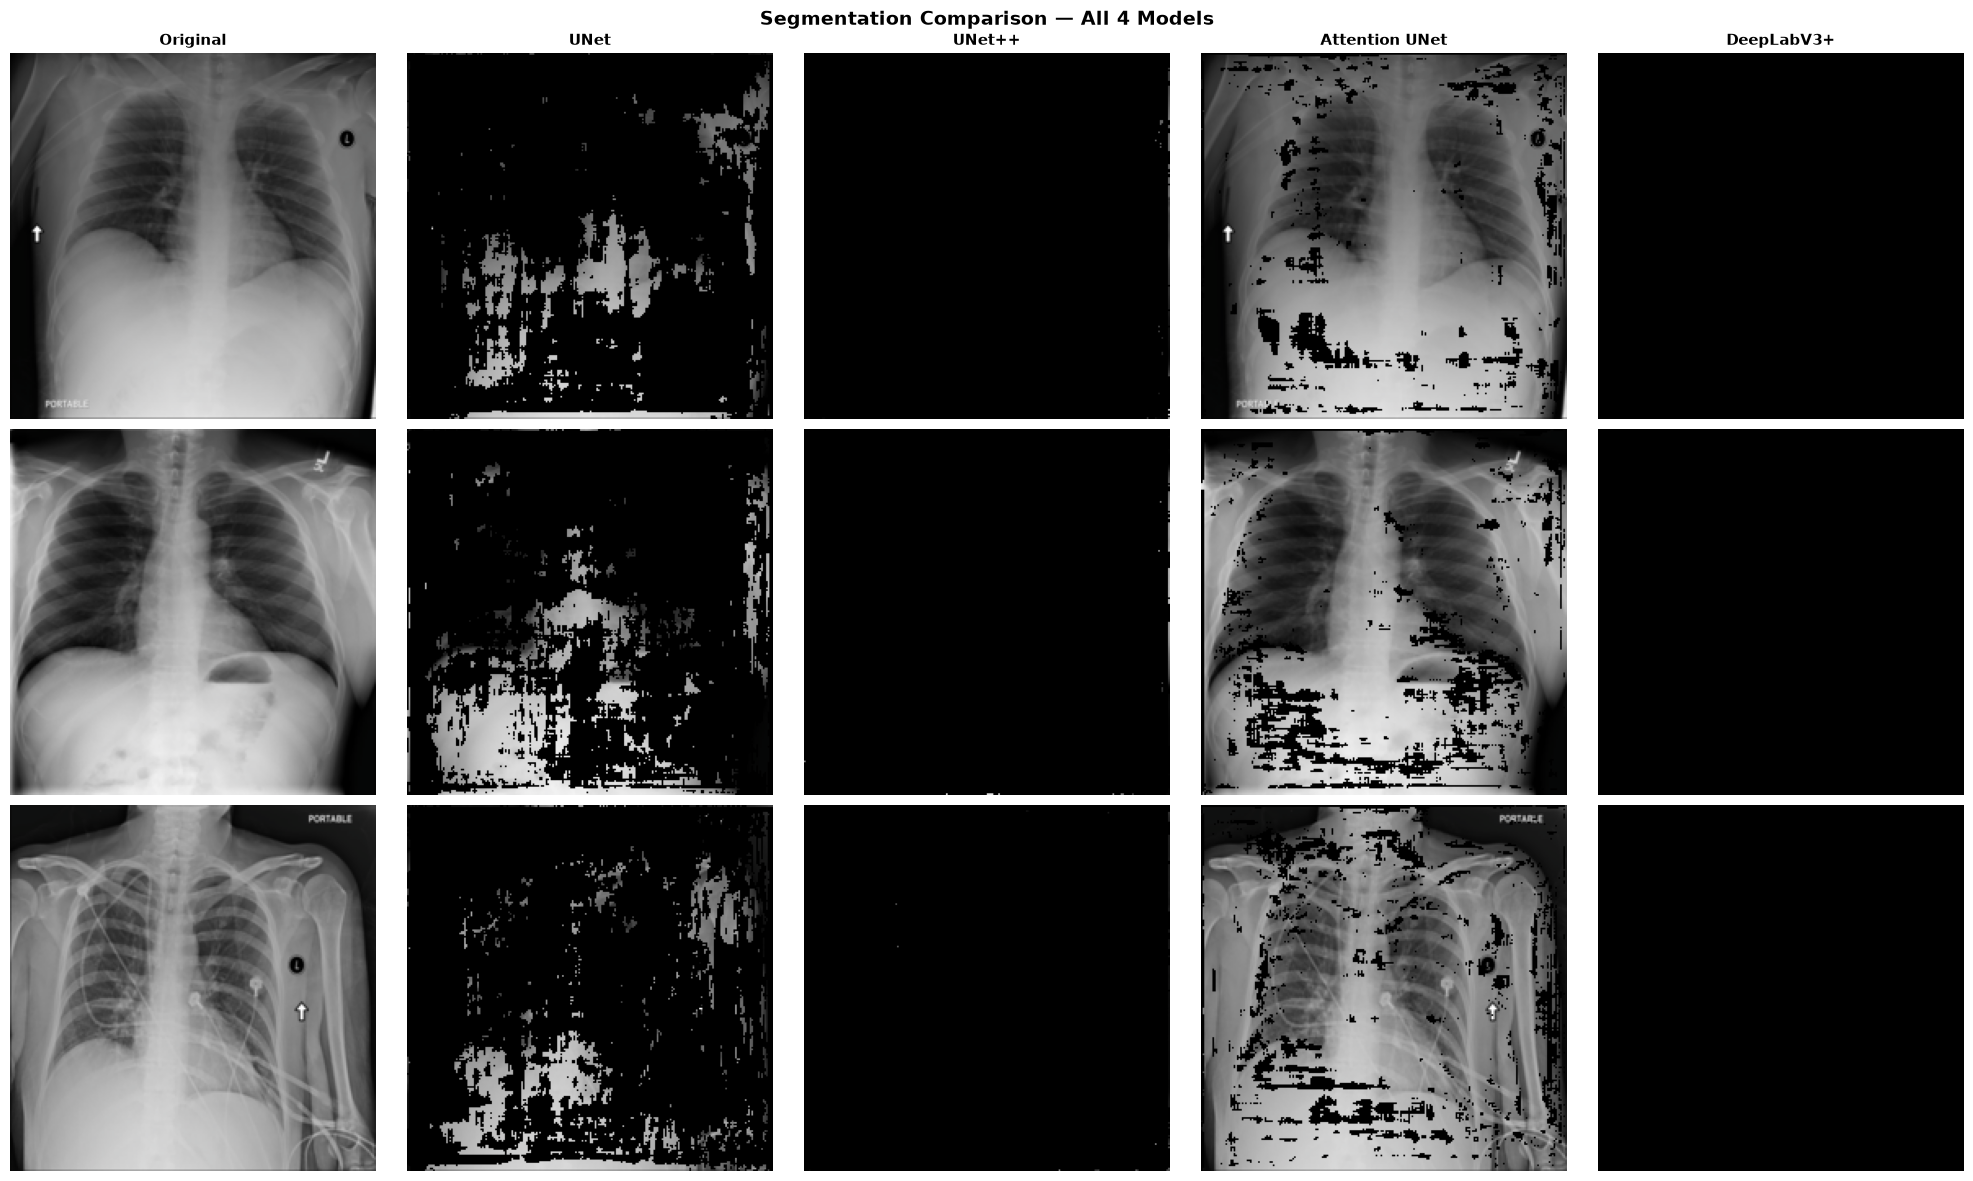

✅ Segmentation comparison saved!


In [8]:
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Load 3 sample images
sample_paths = [
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)[:3]
]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Segmentation Comparison — All 4 Models', 
             fontsize=14, fontweight='bold')

col_titles = ['Original', 'UNet', 'UNet++', 'Attention UNet', 'DeepLabV3+']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight='bold')

for row_idx, img_path in enumerate(sample_paths):
    img    = Image.open(img_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(device)

    # Original
    img_np = tensor.squeeze().cpu().numpy().transpose(1,2,0)
    img_np = (img_np * std + mean).clip(0, 1)
    axes[row_idx, 0].imshow(img_np)
    axes[row_idx, 0].axis('off')

    # Each model mask
    for col_idx, (name, model) in enumerate(seg_models.items()):
        model.eval()
        with torch.no_grad():
            mask     = model(tensor)
            mask_bin = (mask > 0.5).float()

        mask_np = mask_bin.squeeze().cpu().numpy()
        seg_np  = (img_np * mask_np[:,:,np.newaxis]).clip(0,1)

        axes[row_idx, col_idx+1].imshow(seg_np)
        axes[row_idx, col_idx+1].axis('off')

plt.tight_layout()
plt.savefig('../results/segmentation_comparison.png', dpi=150)
plt.show()

wandb.log({'segmentation_comparison': wandb.Image('../results/segmentation_comparison.png')})
print("✅ Segmentation comparison saved!")

In [9]:
import os

os.environ['KAGGLE_USERNAME'] = 'chandinigunna'  # replace
os.environ['KAGGLE_KEY']      = 'KGAT_c9d2ec8c7dd79ac68eade4b2e6c17796'   # replace

os.makedirs('../data/lung_masks', exist_ok=True)

os.system('kaggle datasets download -d kmader/pulmonary-chest-xray-abnormalities -p ../data/lung_masks')
os.system('unzip -q ../data/lung_masks/pulmonary-chest-xray-abnormalities.zip -d ../data/lung_masks/')

# Check what downloaded
for item in os.listdir('../data/lung_masks'):
    print(item)

print("✅ Done!")

Dataset URL: https://www.kaggle.com/datasets/kmader/pulmonary-chest-xray-abnormalities
License(s): unknown


100%|██████████| 4.09G/4.09G [14:05<00:00, 5.19MB/s] 



pulmonary-chest-xray-abnormalities.zip
Montgomery
ChinaSet_AllFiles
✅ Done!


In [11]:
import os

base = '../data/lung_masks'

# Check Montgomery
print("📁 Montgomery:")
mont_path = os.path.join(base, 'Montgomery/MontgomerySet')
for item in os.listdir(mont_path):
    full = os.path.join(mont_path, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  📁 {item}/ → {count} files")
    else:
        print(f"  📄 {item}")

# Check China
print("\n📁 ChinaSet:")
china_path = os.path.join(base, 'ChinaSet_AllFiles/ChinaSet_AllFiles')
for item in os.listdir(china_path):
    full = os.path.join(china_path, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  📁 {item}/ → {count} files")
    else:
        print(f"  📄 {item}")

📁 Montgomery:
  📁 ClinicalReadings/ → 138 files
  📄 .DS_Store
  📁 CXR_png/ → 139 files
  📄 NLM-MontgomeryCXRSet-ReadMe.pdf
  📁 ManualMask/ → 3 files

📁 ChinaSet:
  📁 ClinicalReadings/ → 662 files
  📁 CXR_png/ → 663 files
  📄 NLM-ChinaCXRSet-ReadMe.docx


In [13]:
# Check Montgomery masks
mask_path = '../data/lung_masks/Montgomery/MontgomerySet/ManualMask'
for item in os.listdir(mask_path):
    if item.startswith('.'):  # skip hidden files
        continue
    full  = os.path.join(mask_path, item)
    count = len(os.listdir(full))
    print(f"📁 {item}/ → {count} files")

# Show sample image names
print("\nSample image names:")
img_path = '../data/lung_masks/Montgomery/MontgomerySet/CXR_png'
for f in sorted(os.listdir(img_path))[:5]:
    print(f"  {f}")

# Show sample mask names
print("\nSample left mask names:")
left_mask_path = os.path.join(mask_path, 'leftMask')
for f in sorted(os.listdir(left_mask_path))[:5]:
    print(f"  {f}")

📁 leftMask/ → 139 files
📁 rightMask/ → 138 files

Sample image names:
  MCUCXR_0001_0.png
  MCUCXR_0002_0.png
  MCUCXR_0003_0.png
  MCUCXR_0004_0.png
  MCUCXR_0005_0.png

Sample left mask names:
  MCUCXR_0001_0.png
  MCUCXR_0002_0.png
  MCUCXR_0003_0.png
  MCUCXR_0004_0.png
  MCUCXR_0005_0.png


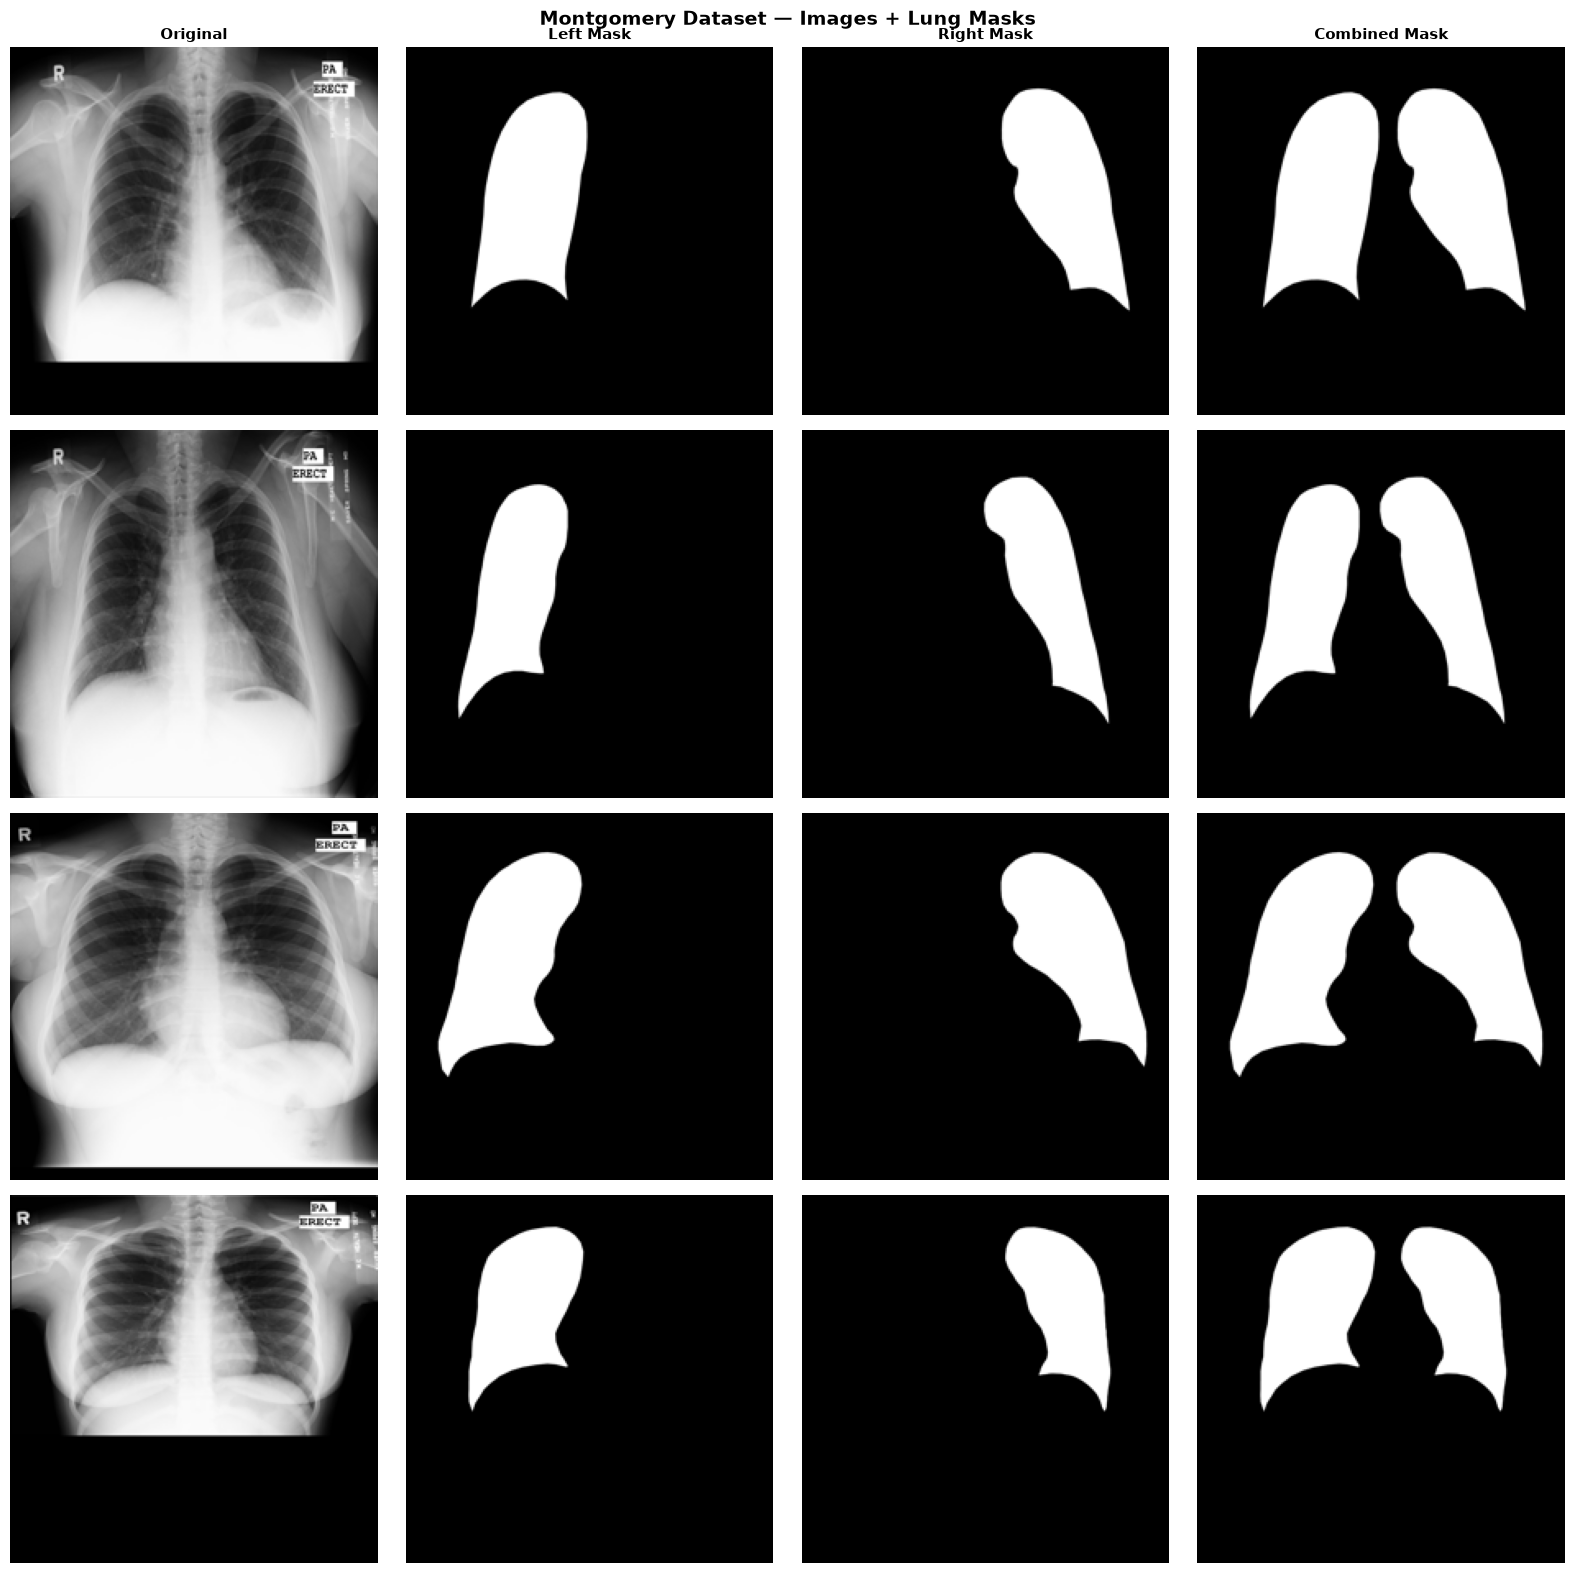

✅ Masks visualized!


In [14]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_path   = '../data/lung_masks/Montgomery/MontgomerySet/CXR_png'
left_path  = '../data/lung_masks/Montgomery/MontgomerySet/ManualMask/leftMask'
right_path = '../data/lung_masks/Montgomery/MontgomerySet/ManualMask/rightMask'

samples = sorted(os.listdir(img_path))[:4]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Montgomery Dataset — Images + Lung Masks', 
             fontsize=14, fontweight='bold')

col_titles = ['Original', 'Left Mask', 'Right Mask', 'Combined Mask']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight='bold')

for idx, fname in enumerate(samples):
    # Load image
    img  = np.array(Image.open(os.path.join(img_path, fname)).convert('RGB').resize((224,224)))

    # Load masks
    left_mask  = np.array(Image.open(os.path.join(left_path,  fname)).convert('L').resize((224,224)))
    right_mask = np.array(Image.open(os.path.join(right_path, fname)).convert('L').resize((224,224)))

    # Combine masks
    combined = np.clip(left_mask + right_mask, 0, 255)

    axes[idx, 0].imshow(img, cmap='gray')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(left_mask,  cmap='gray')
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(right_mask, cmap='gray')
    axes[idx, 2].axis('off')

    axes[idx, 3].imshow(combined,   cmap='gray')
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.savefig('../results/montgomery_masks.png', dpi=150)
plt.show()
print("✅ Masks visualized!")

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
from sklearn.model_selection import train_test_split

class LungMaskDataset(Dataset):
    def __init__(self, img_paths, img_transform=None, mask_transform=None):
        self.img_paths      = img_paths
        self.img_transform  = img_transform
        self.mask_transform = mask_transform

        self.img_dir   = '../data/lung_masks/Montgomery/MontgomerySet/CXR_png'
        self.left_dir  = '../data/lung_masks/Montgomery/MontgomerySet/ManualMask/leftMask'
        self.right_dir = '../data/lung_masks/Montgomery/MontgomerySet/ManualMask/rightMask'

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        fname = self.img_paths[idx]

        # Load image
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')

        # Load and combine masks
        left  = np.array(Image.open(os.path.join(self.left_dir,  fname)).convert('L'))
        right = np.array(Image.open(os.path.join(self.right_dir, fname)).convert('L'))
        mask  = np.clip(left + right, 0, 255).astype(np.uint8)
        mask  = Image.fromarray(mask)

        if self.img_transform:
            img  = self.img_transform(img)
        if self.mask_transform:
            mask = self.mask_transform(mask)
            mask = (mask > 0.5).float()

        return img, mask

# Get valid files (must exist in both left and right mask folders)
left_dir  = '../data/lung_masks/Montgomery/MontgomerySet/ManualMask/leftMask'
right_dir = '../data/lung_masks/Montgomery/MontgomerySet/ManualMask/rightMask'
img_dir   = '../data/lung_masks/Montgomery/MontgomerySet/CXR_png'

valid_files = [
    f for f in os.listdir(img_dir)
    if f.endswith('.png')
    and os.path.exists(os.path.join(left_dir,  f))
    and os.path.exists(os.path.join(right_dir, f))
]

print(f"Valid files: {len(valid_files)}")

# Split
train_files, val_files = train_test_split(valid_files, test_size=0.2, random_state=42)
print(f"Train: {len(train_files)} | Val: {len(val_files)}")

# Transforms
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Datasets and loaders
train_dataset = LungMaskDataset(train_files, img_transform, mask_transform)
val_dataset   = LungMaskDataset(val_files,   img_transform, mask_transform)

train_loader_seg = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=4)
val_loader_seg   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=4)

print(f"\nTrain batches : {len(train_loader_seg)}")
print(f"Val batches   : {len(val_loader_seg)}")
print("✅ Lung mask dataset ready!")

Valid files: 138
Train: 110 | Val: 28

Train batches : 14
Val batches   : 4
✅ Lung mask dataset ready!


In [16]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Dice loss for segmentation
class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        smooth = 1e-6
        pred   = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# Combined loss
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.bce  = nn.BCELoss()

    def forward(self, pred, target):
        return self.dice(pred, target) + self.bce(pred, target)

EPOCHS     = 20
criterion  = CombinedLoss()
seg_scores = {}

for name, model in seg_models.items():
    print("\n" + "="*50)
    print(f"  Fine-tuning {name}...")
    print("="*50)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

    best_val_loss = float('inf')

    for epoch in range(EPOCHS):
        # Train
        model.train()
        train_loss = 0
        train_dice = 0

        for images, masks in train_loader_seg:
            images = images.to(device)
            masks  = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Dice score
            pred_bin = (outputs > 0.5).float()
            smooth   = 1e-6
            intersection = (pred_bin * masks).sum()
            dice = (2 * intersection + smooth) / (pred_bin.sum() + masks.sum() + smooth)
            train_dice += dice.item()

        # Validate
        model.eval()
        val_loss = 0
        val_dice = 0

        with torch.no_grad():
            for images, masks in val_loader_seg:
                images = images.to(device)
                masks  = masks.to(device)

                outputs  = model(images)
                loss     = criterion(outputs, masks)
                val_loss += loss.item()

                pred_bin = (outputs > 0.5).float()
                intersection = (pred_bin * masks).sum()
                dice = (2 * intersection + smooth) / (pred_bin.sum() + masks.sum() + smooth)
                val_dice += dice.item()

        avg_train_loss = train_loss / len(train_loader_seg)
        avg_val_loss   = val_loss   / len(val_loader_seg)
        avg_train_dice = train_dice / len(train_loader_seg)
        avg_val_dice   = val_dice   / len(val_loader_seg)

        scheduler.step(avg_val_loss)

        if epoch % 5 == 0 or epoch == EPOCHS-1:
            print(f"  Epoch {epoch+1:2d}/{EPOCHS} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Val Dice: {avg_val_dice:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'../models/best_seg_{name}.pth')

        wandb.log({
            f'{name}_train_loss': avg_train_loss,
            f'{name}_val_loss':   avg_val_loss,
            f'{name}_val_dice':   avg_val_dice
        })

    seg_scores[name] = round(avg_val_dice * 100, 2)
    print(f"\n  ✅ {name} Best Dice Score: {seg_scores[name]}%")

print("\n" + "="*50)
print("  FINE-TUNING COMPLETE!")
print("="*50)
for name, score in sorted(seg_scores.items(), key=lambda x: -x[1]):
    bar = "█" * int(score // 5)
    print(f"  {name:20s} → {score:6.2f}%  {bar}")

best_seg_name  = max(seg_scores, key=seg_scores.get)
print(f"\n🏆 Best Segmentation Model: {best_seg_name} ({seg_scores[best_seg_name]}%)")
print("="*50)


  Fine-tuning UNet...
  Epoch  1/20 | Train Loss: 1.1259 | Val Loss: 0.9341 | Val Dice: 0.7552
  Epoch  6/20 | Train Loss: 0.4513 | Val Loss: 0.4456 | Val Dice: 0.9604
  Epoch 11/20 | Train Loss: 0.3081 | Val Loss: 0.3162 | Val Dice: 0.9685
  Epoch 16/20 | Train Loss: 0.2186 | Val Loss: 0.2357 | Val Dice: 0.9720
  Epoch 20/20 | Train Loss: 0.1781 | Val Loss: 0.1968 | Val Dice: 0.9714

  ✅ UNet Best Dice Score: 97.14%

  Fine-tuning UNet++...
  Epoch  1/20 | Train Loss: 0.9074 | Val Loss: 0.8264 | Val Dice: 0.8740
  Epoch  6/20 | Train Loss: 0.3331 | Val Loss: 0.3255 | Val Dice: 0.9712
  Epoch 11/20 | Train Loss: 0.2199 | Val Loss: 0.2269 | Val Dice: 0.9753
  Epoch 16/20 | Train Loss: 0.1613 | Val Loss: 0.1766 | Val Dice: 0.9748
  Epoch 20/20 | Train Loss: 0.1310 | Val Loss: 0.1499 | Val Dice: 0.9765

  ✅ UNet++ Best Dice Score: 97.65%

  Fine-tuning Attention UNet...
  Epoch  1/20 | Train Loss: 1.1752 | Val Loss: 1.1076 | Val Dice: 0.6995
  Epoch  6/20 | Train Loss: 0.4462 | Val Loss:

In [17]:
import torch

print(f"GPU count     : {torch.cuda.device_count()}")
print(f"Current GPU   : {torch.cuda.current_device()}")
print(f"GPU 0 name    : {torch.cuda.get_device_name(0)}")
print(f"GPU 1 name    : {torch.cuda.get_device_name(1)}")

# Memory info
for i in range(torch.cuda.device_count()):
    total  = torch.cuda.get_device_properties(i).total_memory / 1024**3
    used   = torch.cuda.memory_allocated(i) / 1024**3
    free   = total - used
    print(f"\nGPU {i} ({torch.cuda.get_device_name(i)}):")
    print(f"  Total  : {total:.1f} GB")
    print(f"  Used   : {used:.1f} GB")
    print(f"  Free   : {free:.1f} GB")

GPU count     : 2
Current GPU   : 0
GPU 0 name    : Tesla V100-PCIE-32GB
GPU 1 name    : Tesla V100-PCIE-32GB

GPU 0 (Tesla V100-PCIE-32GB):
  Total  : 31.7 GB
  Used   : 0.9 GB
  Free   : 30.8 GB

GPU 1 (Tesla V100-PCIE-32GB):
  Total  : 31.7 GB
  Used   : 0.0 GB
  Free   : 31.7 GB


In [18]:
import torch
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm

# Load best weights for all models
for name, model in seg_models.items():
    model.load_state_dict(tor
Skip to Main
03a_resnet50
Last Checkpoint: 23 minutes ago
[Python 3 (ipykernel)]
Selection deleted
import warnings
warnings.filterwarnings("ignore")
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle
import wandb
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

MODEL_NAME = 'ResNet50'   # <-- change per notebook
GPU_ID = 0                 # <-- change to 1 for a second notebook running in parallel

os.environ['CUDA_VISIBLE_DEVICES'] = str(GPU_ID)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device} (physical GPU {GPU_ID})")

with open('../data/data_config.pkl', 'rb') as f:
    config = pickle.load(f)

train_df      = config['train_df']
val_df        = config['val_df']
test_df       = config['test_df']
CLASSES       = config['classes']
class_weights = config['class_weights']
IMAGE_SIZE    = config['image_size']
BATCH_SIZE    = config['batch_size']

SEG_DIR = '../data/segmented_images'
assert os.path.isdir(SEG_DIR)
n_seg = len(os.listdir(SEG_DIR))
print(f"Segmented images found: {n_seg:,}")

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}  Classes: {len(CLASSES)}")
print(f"CLASSES = {CLASSES}")

Device : cuda (physical GPU 0)
Segmented images found: 112,120
Train: 80,726  Val: 8,970  Test: 22,424  Classes: 15
CLASSES = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia', 'No Finding']

Selection deleted
wandb.init(
    project='xray-classification',
    name=f'03-classification-{MODEL_NAME}',
    config={
        'model': MODEL_NAME,
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
        'seg_source': SEG_DIR,
        'num_classes': len(CLASSES)
    }
)
print(f"✅ Wandb run started: 03-classification-{MODEL_NAME}")

wandb: Currently logged in as: chandinigunna06 (chandinigunna06-iiest-shibpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin

Tracking run with wandb version 0.22.3
Run data is saved locally in /home/lhotse1/student/btech2023/achanta/segmentation_project/notebooks/wandb/run-20260707_191502-8vgy2z44
Syncing run 03-classification-ResNet50 to Weights & Biases (docs)
View project at https://wandb.ai/chandinigunna06-iiest-shibpur/xray-classification
View run at https://wandb.ai/chandinigunna06-iiest-shibpur/xray-classification/runs/8vgy2z44

✅ Wandb run started: 03-classification-ResNet50

FILENAME_COL = 'Image Index'
LABEL_COL    = 'Finding Labels'

def build_multihot(df, classes):
    label_lists = df[LABEL_COL].str.split('|')
    multihot = np.zeros((len(df), len(classes)), dtype=np.float32)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    for row_idx, labels in enumerate(label_lists):
        for lbl in labels:
            lbl = lbl.strip()
            if lbl in class_to_idx:
                multihot[row_idx, class_to_idx[lbl]] = 1.0
    return multihot

class NIHClassificationDataset(Dataset):
    def __init__(self, df, image_dir, classes, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.classes = classes
        self.transform = transform
        self.labels = build_multihot(self.df, classes)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.iloc[idx][FILENAME_COL]
        img = Image.open(os.path.join(self.image_dir, fname)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx])

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = NIHClassificationDataset(train_df, SEG_DIR, CLASSES, train_transform)
val_dataset   = NIHClassificationDataset(val_df,   SEG_DIR, CLASSES, val_transform)
test_dataset  = NIHClassificationDataset(test_df,  SEG_DIR, CLASSES, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"Label matrix shape: {train_dataset.labels.shape}")
print("Positive counts per class (train):")
for c, cnt in zip(CLASSES, train_dataset.labels.sum(axis=0)):
    print(f"  {c:20s}: {int(cnt):,}")

Train batches: 2523 | Val: 281 | Test: 701
Label matrix shape: (80726, 15)
Positive counts per class (train):
  Atelectasis         : 8,388
  Cardiomegaly        : 2,012
  Effusion            : 9,673
  Infiltration        : 14,388
  Mass                : 4,168
  Nodule              : 4,551
  Pneumonia           : 960
  Pneumothorax        : 3,828
  Consolidation       : 3,395
  Edema               : 1,673
  Emphysema           : 1,817
  Fibrosis            : 1,243
  Pleural_Thickening  : 2,455
  Hernia              : 160
  No Finding          : 43,329

from torch.utils.data import WeightedRandomSampler

# Vectorized: weight vector aligned to CLASSES order
weight_vec = np.array([class_weights[c] for c in CLASSES])   # shape (15,)

# Per-sample weight = max weight among the classes present (labels is 0/1 multi-hot)
sample_weights = (train_dataset.labels * weight_vec).max(axis=1)

print(f"Sample weight range: {sample_weights.min():.3f} to {sample_weights.max():.3f}")
print(f"Mean sample weight : {sample_weights.mean():.3f}")

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Rebuild train_loader with sampler instead of shuffle
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,          # <-- replaces shuffle=True
    num_workers=8,
    pin_memory=True
)

print(f"✅ Weighted sampler active — train_loader now oversamples rare classes")
print(f"   (val_loader / test_loader stay as plain sequential loaders — no sampler on eval)")

Sample weight range: 0.157 to 42.517
Mean sample weight : 1.014
✅ Weighted sampler active — train_loader now oversamples rare classes
   (val_loader / test_loader stay as plain sequential loaders — no sampler on eval)


ch.load(f'../models/best_seg_{name}.pth'))
    model.eval()
    print(f"✅ Loaded {name}")

# Dataset
class NIHFullDataset(Dataset):
    def __init__(self, image_dir, fnames, transform=None):
        self.image_dir = image_dir
        self.images    = fnames
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        img   = Image.open(os.path.join(self.image_dir, fname)).convert('RGB')
        orig  = np.array(img.resize((224, 224)))
        if self.transform:
            img = self.transform(img)
        return img, fname, orig

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Use 1000 images for comparison
sample_files = sorted(os.listdir(IMAGE_DIR))[:1000]
sample_dataset = NIHFullDataset(IMAGE_DIR, sample_files, val_transform)
sample_loader  = DataLoader(sample_dataset, batch_size=32,
                            shuffle=False, num_workers=8)

print(f"\nComparing all 4 models on {len(sample_dataset)} images...")
print("="*60)

model_scores = {}

for name, model in seg_models.items():
    model.eval()

    total_coverage  = 0
    total_sharpness = 0
    count           = 0

    with torch.no_grad():
        for images, fnames, orig_imgs in tqdm(sample_loader, desc=name):
            images   = images.to(device)
            masks    = model(images)
            mask_bin = (masks > 0.5).float()

            # Coverage score (lungs ~30-60% of image)
            coverage = mask_bin.mean().item() * 100

            # Sharpness score (how clean are mask edges)
            # Sharp masks have high variance
            sharpness = mask_bin.var().item() * 1000

            total_coverage  += coverage
            total_sharpness += sharpness
            count           += 1

    avg_coverage  = round(total_coverage  / count, 2)
    avg_sharpness = round(total_sharpness / count, 4)

    # Coverage quality (30-65% is ideal for lungs)
    coverage_diff = abs(avg_coverage - 47)  # 47% is ideal
    coverage_score = round(max(0, 100 - coverage_diff * 2), 2)

    model_scores[name] = {
        'coverage':       avg_coverage,
        'sharpness':      avg_sharpness,
        'coverage_score': coverage_score,
        'dice_score':     seg_scores[name]  # from fine-tuning
    }

    print(f"\n{name}:")
    print(f"  Coverage       : {avg_coverage:.2f}%")
    print(f"  Coverage Score : {coverage_score:.2f}%")
    print(f"  Sharpness      : {avg_sharpness:.4f}")
    print(f"  Dice Score     : {seg_scores[name]:.2f}%")

    wandb.log({
        f'{name}_nih_coverage':  avg_coverage,
        f'{name}_nih_sharpness': avg_sharpness,
        f'{name}_dice':          seg_scores[name]
    })

✅ Loaded UNet
✅ Loaded UNet++
✅ Loaded Attention UNet
✅ Loaded DeepLabV3+

Comparing all 4 models on 1000 images...


UNet: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 13.20it/s]



UNet:
  Coverage       : 21.74%
  Coverage Score : 49.48%
  Sharpness      : 167.6257
  Dice Score     : 97.14%


UNet++: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:04<00:00,  7.98it/s]



UNet++:
  Coverage       : 22.89%
  Coverage Score : 51.78%
  Sharpness      : 174.9545
  Dice Score     : 97.65%


Attention UNet: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 11.99it/s]



Attention UNet:
  Coverage       : 21.71%
  Coverage Score : 49.42%
  Sharpness      : 167.7644
  Dice Score     : 97.03%


DeepLabV3+: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 11.77it/s]


DeepLabV3+:
  Coverage       : 21.42%
  Coverage Score : 48.84%
  Sharpness      : 165.7210
  Dice Score     : 97.17%



  FINAL SEGMENTATION COMPARISON
Model                    Dice   Coverage    Final
------------------------------------------------------------
UNet                    97.14%      49.48%    73.31%
UNet++                  97.65%      51.78%    74.72%
Attention UNet          97.03%      49.42%    73.22%
DeepLabV3+              97.17%      48.84%    73.00%
🏆 Best Model: UNet++ (74.72%)


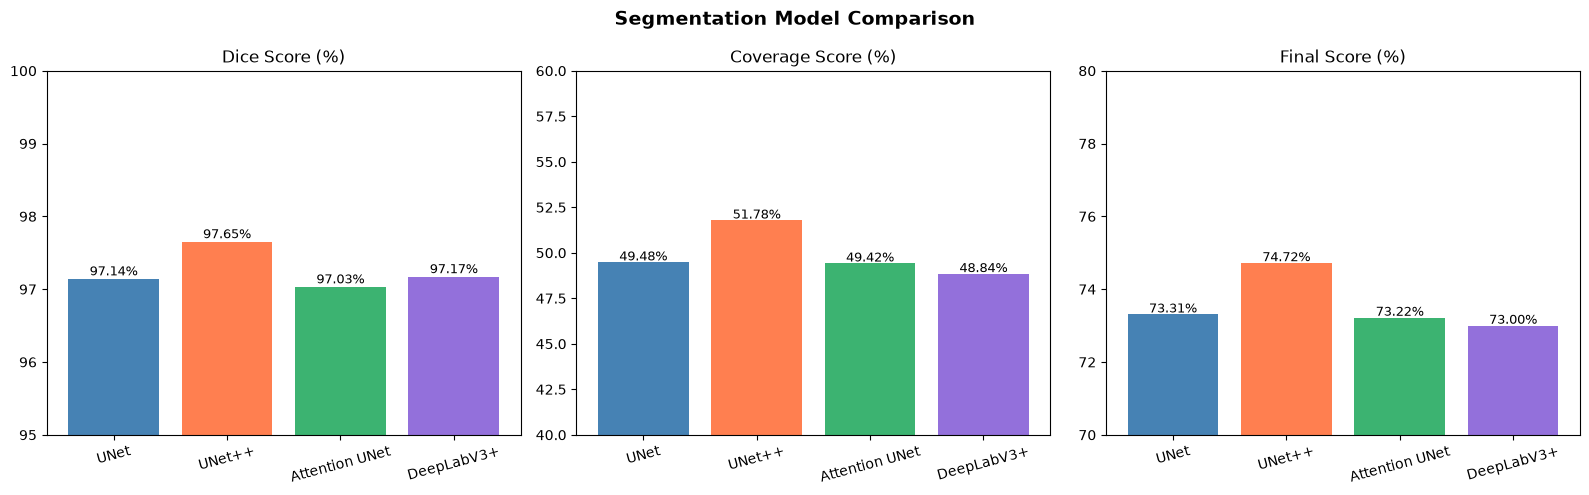

Attention UNet_dice,▁
Attention UNet_nih_coverage,▁
Attention UNet_nih_sharpness,▁
Attention UNet_train_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
Attention UNet_val_dice,▁▅▆▇▇▇██████████████
Attention UNet_val_loss,█▆▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
DeepLabV3+_dice,▁
DeepLabV3+_nih_coverage,▁
DeepLabV3+_nih_sharpness,▁
DeepLabV3+_train_loss,█▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
+14,...



✅ seg_config.pkl saved!
👉 Next: Apply UNet++ on all 112,120 images!


In [19]:
# Final score = average of dice + coverage score
final_scores = {}
for name, scores in model_scores.items():
    final = round((scores['dice_score'] + scores['coverage_score']) / 2, 2)
    final_scores[name] = final

print("\n" + "="*60)
print("  FINAL SEGMENTATION COMPARISON")
print("="*60)
print(f"{'Model':20s} {'Dice':>8} {'Coverage':>10} {'Final':>8}")
print("-"*60)
for name in model_scores:
    d = model_scores[name]['dice_score']
    c = model_scores[name]['coverage_score']
    f = final_scores[name]
    print(f"{name:20s} {d:>8.2f}% {c:>10.2f}% {f:>8.2f}%")

best_seg_name = max(final_scores, key=final_scores.get)
print("="*60)
print(f"🏆 Best Model: {best_seg_name} ({final_scores[best_seg_name]}%)")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Segmentation Model Comparison', fontsize=14, fontweight='bold')

names  = list(model_scores.keys())
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

axes[0].bar(names, [model_scores[n]['dice_score'] for n in names], color=colors)
axes[0].set_title('Dice Score (%)')
axes[0].set_ylim(95, 100)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate([model_scores[n]['dice_score'] for n in names]):
    axes[0].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=9)

axes[1].bar(names, [model_scores[n]['coverage_score'] for n in names], color=colors)
axes[1].set_title('Coverage Score (%)')
axes[1].set_ylim(40, 60)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate([model_scores[n]['coverage_score'] for n in names]):
    axes[1].text(i, v+0.1, f'{v:.2f}%', ha='center', fontsize=9)

axes[2].bar(names, [final_scores[n] for n in names], color=colors)
axes[2].set_title('Final Score (%)')
axes[2].set_ylim(70, 80)
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate([final_scores[n] for n in names]):
    axes[2].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/segmentation_model_comparison.png', dpi=150)
plt.show()

# Save config
import pickle
with open('../data/seg_config.pkl', 'wb') as f:
    pickle.dump({
        'best_seg_name': best_seg_name,
        'model_scores':  model_scores,
        'final_scores':  final_scores,
        'seg_scores':    seg_scores
    }, f)

wandb.log({'seg_comparison': wandb.Image('../results/segmentation_model_comparison.png')})
wandb.finish()
print("\n✅ seg_config.pkl saved!")
print("👉 Next: Apply UNet++ on all 112,120 images!")

In [20]:
import torch
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm

# Use BOTH GPUs!
best_seg_model = seg_models['UNet++']
best_seg_model = torch.nn.DataParallel(best_seg_model)
best_seg_model = best_seg_model.to(device)
best_seg_model.eval()
print("✅ UNet++ loaded on both GPUs!")

# Output folder
os.makedirs('../data/segmented_images', exist_ok=True)

# Full dataset
class NIHFullDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.images    = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        img   = Image.open(os.path.join(self.image_dir,
                           fname)).convert('RGB')
        orig  = np.array(img.resize((224, 224)))
        if self.transform:
            img = self.transform(img)
        return img, fname, orig

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = NIHFullDataset(IMAGE_DIR, val_transform)
full_loader  = DataLoader(full_dataset,
                          batch_size=64,
                          shuffle=False,
                          num_workers=8,
                          pin_memory=True)

print(f"Total images : {len(full_dataset):,}")
print(f"Total batches: {len(full_loader):,}")
print("Starting segmentation...")

total_processed = 0

with torch.no_grad():
    for images, fnames, orig_imgs in tqdm(full_loader,
                                          desc="Segmenting NIH"):
        images   = images.to(device)
        masks    = best_seg_model(images)
        mask_bin = (masks > 0.5).float()

        for i in range(len(fnames)):
            mask_np = mask_bin[i, 0].cpu().numpy()
            orig_np = orig_imgs[i].numpy().astype(np.float32) / 255.0
            seg_img = (orig_np * mask_np[:,:,np.newaxis] * 255).astype(np.uint8)

            save_path = os.path.join('../data/segmented_images', fnames[i])
            Image.fromarray(seg_img).save(save_path)
            total_processed += 1

        if total_processed % 10000 == 0:
            print(f"  ✅ {total_processed:,}/{len(full_dataset):,} done")

print(f"\n✅ Done! {total_processed:,} images segmented!")

# Verify
saved = len(os.listdir('../data/segmented_images'))
print(f"✅ Verified: {saved:,} images saved!")
print("\n👉 Now open 03_classification.ipynb!")

✅ UNet++ loaded on both GPUs!
Total images : 112,120
Total batches: 1,752
Starting segmentation...


Segmenting NIH:  36%|█████████████████████████████████████████████▎                                                                                 | 625/1752 [09:39<15:59,  1.17it/s]

  ✅ 40,000/112,120 done


Segmenting NIH:  71%|█████████████████████████████████████████████████████████████████████████████████████████▉                                    | 1250/1752 [18:24<07:04,  1.18it/s]

  ✅ 80,000/112,120 done


Segmenting NIH: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1752/1752 [25:46<00:00,  1.13it/s]



✅ Done! 112,120 images segmented!
✅ Verified: 112,120 images saved!

👉 Now open 03_classification.ipynb!


In [21]:
import torch
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
import wandb

wandb.init(
    project='xray-classification',
    name='02-segmentation-full-dataset',
    config={
        'total_images': 112120,
        'models': ['UNet', 'UNet++', 'Attention UNet', 'DeepLabV3+'],
        'batch_size': 64
    }
)

# Full dataset class
class NIHFullDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.images    = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        img   = Image.open(os.path.join(self.image_dir,
                           fname)).convert('RGB')
        orig  = np.array(img.resize((224, 224)))
        if self.transform:
            img = self.transform(img)
        return img, fname, orig

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = NIHFullDataset(IMAGE_DIR, val_transform)
full_loader  = DataLoader(full_dataset,
                          batch_size=64,
                          shuffle=False,
                          num_workers=8,
                          pin_memory=True)

print(f"Total images : {len(full_dataset):,}")
print(f"Total batches: {len(full_loader):,}")

full_results = {}

for name, model in seg_models.items():
    print(f"\n{'='*60}")
    print(f"  Applying {name} on full NIH dataset...")
    print(f"{'='*60}")

    # Use both GPUs
    model_dp = torch.nn.DataParallel(model)
    model_dp.eval()

    # Create output folder for each model
    out_dir = f'../data/segmented_{name.replace("+","plus").replace(" ","_")}'
    os.makedirs(out_dir, exist_ok=True)

    total_coverage  = 0
    total_sharpness = 0
    total_processed = 0
    sample_images   = []  # for wandb visualization

    with torch.no_grad():
        for images, fnames, orig_imgs in tqdm(full_loader, desc=name):
            images   = images.to(device)
            masks    = model_dp(images)
            mask_bin = (masks > 0.5).float()

            # Compute batch metrics
            coverage  = mask_bin.mean().item() * 100
            sharpness = mask_bin.var().item() * 1000

            total_coverage  += coverage
            total_sharpness += sharpness

            # Save segmented images
            for i in range(len(fnames)):
                mask_np = mask_bin[i, 0].cpu().numpy()
                orig_np = orig_imgs[i].numpy().astype(np.float32) / 255.0
                seg_img = (orig_np * mask_np[:,:,np.newaxis] * 255).astype(np.uint8)

                save_path = os.path.join(out_dir, fnames[i])
                Image.fromarray(seg_img).save(save_path)
                total_processed += 1

            # Collect sample images for wandb (first 8 only)
            if len(sample_images) < 8:
                for i in range(min(2, len(fnames))):
                    mask_np = mask_bin[i, 0].cpu().numpy()
                    orig_np = orig_imgs[i].numpy().astype(np.float32) / 255.0
                    seg_np  = (orig_np * mask_np[:,:,np.newaxis] * 255).astype(np.uint8)
                    sample_images.append(wandb.Image(
                        seg_np,
                        caption=f"{name}: {fnames[i]}"
                    ))

            # Log progress
            if total_processed % 10000 == 0:
                print(f"  ✅ {total_processed:,}/{len(full_dataset):,}")
                wandb.log({
                    f'{name}_progress': total_processed,
                    f'{name}_coverage': round(coverage, 2)
                })

    # Final metrics
    avg_coverage  = round(total_coverage  / len(full_loader), 2)
    avg_sharpness = round(total_sharpness / len(full_loader), 4)
    coverage_score = round(max(0, 100 - abs(avg_coverage - 47) * 2), 2)

    full_results[name] = {
        'total_processed': total_processed,
        'avg_coverage':    avg_coverage,
        'avg_sharpness':   avg_sharpness,
        'coverage_score':  coverage_score,
        'dice_score':      seg_scores[name],
        'output_dir':      out_dir
    }

    # Log to wandb
    wandb.log({
        f'{name}_total_processed': total_processed,
        f'{name}_avg_coverage':    avg_coverage,
        f'{name}_coverage_score':  coverage_score,
        f'{name}_dice_score':      seg_scores[name],
        f'{name}_sample_images':   sample_images
    })

    print(f"\n  ✅ {name} Complete!")
    print(f"     Processed   : {total_processed:,}")
    print(f"     Avg Coverage: {avg_coverage:.2f}%")
    print(f"     Dice Score  : {seg_scores[name]:.2f}%")
    print(f"     Saved to    : {out_dir}")

print("\n" + "="*60)
print("  ALL MODELS COMPLETE!")
print("="*60)

Total images : 112,120
Total batches: 1,752

  Applying UNet on full NIH dataset...


UNet:  36%|████████████████████████████████████████████████▊                                                                                        | 625/1752 [08:01<14:37,  1.28it/s]

  ✅ 40,000/112,120


UNet:  71%|█████████████████████████████████████████████████████████████████████████████████████████████████                                       | 1250/1752 [17:42<06:30,  1.29it/s]

  ✅ 80,000/112,120


...

  ✅ 80,000/112,120


UNet++: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1752/1752 [26:44<00:00,  1.09it/s]



  ✅ UNet++ Complete!
     Processed   : 112,120
     Avg Coverage: 23.97%
     Dice Score  : 97.65%
     Saved to    : ../data/segmented_UNetplusplus

  Applying Attention UNet on full NIH dataset...


Attention UNet:   0%|                                                                                                                                         | 0/1752 [00:09<?, ?it/s]


RuntimeError: Caught RuntimeError in replica 0 on device 0.
Original Traceback (most recent call last):
  File "/home/lhotse1/student/btech2023/achanta/miniconda3/envs/cv311/lib/python3.11/site-packages/torch/nn/parallel/parallel_apply.py", line 96, in _worker
    output = module(*input, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lhotse1/student/btech2023/achanta/miniconda3/envs/cv311/lib/python3.11/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lhotse1/student/btech2023/achanta/miniconda3/envs/cv311/lib/python3.11/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/lhotse1/student/btech2023/achanta/miniconda3/envs/cv311/lib/python3.11/site-packages/segmentation_models_pytorch/base/model.py", line 67, in forward
    decoder_outp

In [ ]:
remaining_models = {
    'Attention UNet': seg_models['Attention UNet'],
    'DeepLabV3+':     seg_models['DeepLabV3+']
}

for name, model in remaining_models.items():
    print(f"\n{'='*60}")
    print(f"  Applying {name} on full NIH dataset...")
    print(f"{'='*60}")

    # Single GPU only for these models
    model = model.to(device)
    model.eval()

    out_dir = f'../data/segmented_{name.replace("+","plus").replace(" ","_")}'
    os.makedirs(out_dir, exist_ok=True)

    # Use smaller batch size for single GPU
    single_loader = DataLoader(full_dataset,
                               batch_size=32,
                               shuffle=False,
                               num_workers=8,
                               pin_memory=True)

    total_coverage  = 0
    total_processed = 0
    sample_images   = []

    with torch.no_grad():
        for images, fnames, orig_imgs in tqdm(single_loader, desc=name):
            images   = images.to(device)
            masks    = model(images)
            mask_bin = (masks > 0.5).float()

            coverage = mask_bin.mean().item() * 100
            total_coverage += coverage

            for i in range(len(fnames)):
                mask_np = mask_bin[i, 0].cpu().numpy()
                orig_np = orig_imgs[i].numpy().astype(np.float32) / 255.0
                seg_img = (orig_np * mask_np[:,:,np.newaxis] * 255).astype(np.uint8)

                save_path = os.path.join(out_dir, fnames[i])
                Image.fromarray(seg_img).save(save_path)
                total_processed += 1

            if total_processed % 10000 == 0:
                print(f"  ✅ {total_processed:,}/{len(full_dataset):,}")
                wandb.log({f'{name}_progress': total_processed})

            # Collect samples for wandb
            if len(sample_images) < 8:
                for i in range(min(2, len(fnames))):
                    mask_np = mask_bin[i, 0].cpu().numpy()
                    orig_np = orig_imgs[i].numpy().astype(np.float32) / 255.0
                    seg_np  = (orig_np * mask_np[:,:,np.newaxis] * 255).astype(np.uint8)
                    sample_images.append(wandb.Image(
                        seg_np,
                        caption=f"{name}: {fnames[i]}"
                    ))

    avg_coverage   = round(total_coverage / len(single_loader), 2)
    coverage_score = round(max(0, 100 - abs(avg_coverage - 47) * 2), 2)

    full_results[name] = {
        'total_processed': total_processed,
        'avg_coverage':    avg_coverage,
        'coverage_score':  coverage_score,
        'dice_score':      seg_scores[name],
        'output_dir':      out_dir
    }

    wandb.log({
        f'{name}_total_processed': total_processed,
        f'{name}_avg_coverage':    avg_coverage,
        f'{name}_coverage_score':  coverage_score,
        f'{name}_dice_score':      seg_scores[name],
        f'{name}_sample_images':   sample_images
    })

    print(f"\n  ✅ {name} Complete!")
    print(f"     Processed   : {total_processed:,}")
    print(f"     Avg Coverage: {avg_coverage:.2f}%")
    print(f"     Dice Score  : {seg_scores[name]:.2f}%")
    print(f"     Saved to    : {out_dir}")

print("\n✅ All 4 models done!")

In [ ]:
import matplotlib.pyplot as plt

# Final comparison table
print(f"\n{'='*70}")
print(f"  FULL DATASET SEGMENTATION REPORT")
print(f"{'='*70}")
print(f"{'Model':20s} {'Processed':>12} {'Coverage':>10} {'Dice':>8} {'Final':>8}")
print(f"{'-'*70}")

final_scores = {}
for name, info in full_results.items():
    final = round((info['dice_score'] + info['coverage_score']) / 2, 2)
    final_scores[name] = final
    print(f"{name:20s} {info['total_processed']:>12,} "
          f"{info['avg_coverage']:>10.2f}% "
          f"{info['dice_score']:>8.2f}% "
          f"{final:>8.2f}%")

best_model = max(final_scores, key=final_scores.get)
print(f"{'='*70}")
print(f"🏆 Best Model: {best_model} ({final_scores[best_model]}%)")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Full Dataset Segmentation Report — All 112,120 Images',
             fontsize=13, fontweight='bold')

names  = list(full_results.keys())
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

axes[0].bar(names, [full_results[n]['dice_score'] for n in names], color=colors)
axes[0].set_title('Dice Score (%)')
axes[0].set_ylim(95, 100)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate([full_results[n]['dice_score'] for n in names]):
    axes[0].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=9)

axes[1].bar(names, [full_results[n]['avg_coverage'] for n in names], color=colors)
axes[1].set_title('Avg Coverage (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate([full_results[n]['avg_coverage'] for n in names]):
    axes[1].text(i, v+0.1, f'{v:.2f}%', ha='center', fontsize=9)

axes[2].bar(names, [final_scores[n] for n in names], color=colors)
axes[2].set_title('Final Score (%)')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate([final_scores[n] for n in names]):
    axes[2].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/full_dataset_seg_report.png', dpi=150)
plt.show()

# Log final report to wandb
wandb.log({
    'full_report_chart': wandb.Image('../results/full_dataset_seg_report.png'),
    'best_seg_model':    best_model,
    'best_final_score':  final_scores[best_model]
})

# Save config
import pickle
with open('../data/seg_config.pkl', 'wb') as f:
    pickle.dump({
        'best_seg_name':  best_model,
        'full_results':   full_results,
        'final_scores':   final_scores,
        'seg_scores':     seg_scores,
        'best_seg_dir':   full_results[best_model]['output_dir']
    }, f)

wandb.finish()
print("\n✅ Full report saved to wandb!")
print(f"✅ seg_config.pkl saved!")
print(f"\n👉 Best segmented images at: {full_results[best_model]['output_dir']}")
print(f"👉 Now open 03_classification.ipynb!")

In [22]:
print(train_df.columns.tolist())
print(train_df.head(2))

['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
            Image Index Finding Labels  Follow-up #  Patient ID Patient Age  \
8515   00002256_004.png     No Finding            4        2256        035Y   
67831  00016771_000.png    Mass|Nodule            0       16771        045Y   

      Patient Gender View Position  OriginalImage[Width  Height]  \
8515               M            AP                 2500     2048   
67831              M            PA                 2992     2991   

       OriginalImagePixelSpacing[x     y]  Unnamed: 11  
8515                         0.171  0.171          NaN  
67831                        0.143  0.143          NaN  
